In [53]:
import matplotlib.pyplot as plt
import mpmath as mp

In [54]:
# high precision to observe convergence clearly
mp.mp.dps = 200

### Idea: Approximating π using Polygon Geometry

Instead of computing π using series expansions, we approach the problem geometrically.

Consider a regular polygon inscribed in a circle. As the number of sides increases, the polygon approaches the shape of the circle.

Let:
- $R$ be the circumradius (radius of the outer circle)
- $r$ be the inradius (radius of the inner circle)
- $l$ be the side length of the polygon
- $n$ be the number of sides

The perimeter $P = n \cdot l$ satisfies:

$$
2\pi r \leq P \leq 2\pi R
$$

Dividing by $(r + R)$:

$$
\frac{2\pi r}{r+R} \leq \frac{P}{r+R} \leq \frac{2\pi R}{r+R}
$$

As $n \to \infty$, the polygon approaches the circle, so $r \to R$, and by the squeeze principle:

$$
\frac{P}{r+R} \to \pi
$$

Thus, we approximate:

$$
\pi \approx \frac{n \cdot l}{r + R}
$$

This forms the basis of our iterative method.

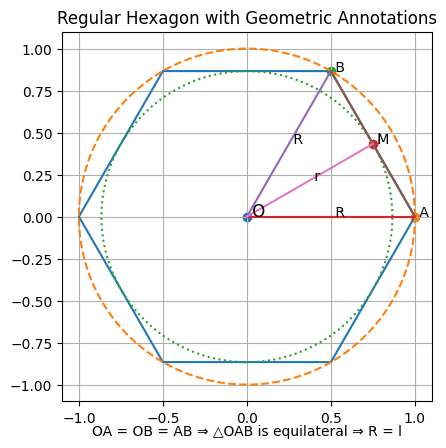

In [55]:
import numpy as np

# Parameters
n = 6
R = 1
center = np.array([0, 0])

# Vertices
angles = np.linspace(0, 2*np.pi, n, endpoint=False)
vertices = np.array([
    [R * np.cos(a), R * np.sin(a)] for a in angles
])

vertices_closed = np.vstack([vertices, vertices[0]])

# Inradius
r = R * np.cos(np.pi / n)

# Circles
theta = np.linspace(0, 2*np.pi, 200)

plt.figure()

# Hexagon
plt.plot(vertices_closed[:, 0], vertices_closed[:, 1])

# Circumcircle
plt.plot(R * np.cos(theta), R * np.sin(theta), linestyle='--')

# Incircle
plt.plot(r * np.cos(theta), r * np.sin(theta), linestyle=':')

# Label center
plt.scatter(0, 0)
plt.text(0, 0, ' O', fontsize=12)

# Label vertices A, B
A = vertices[0]
B = vertices[1]

plt.scatter(A[0], A[1])
plt.text(A[0], A[1], ' A')

plt.scatter(B[0], B[1])
plt.text(B[0], B[1], ' B')

# Midpoint of AB (for r)
mid_AB = (A + B) / 2
mid_AB = mid_AB / np.linalg.norm(mid_AB) * r

plt.scatter(mid_AB[0], mid_AB[1])
plt.text(mid_AB[0], mid_AB[1], ' M')

# Draw radii OA, OB
plt.plot([0, A[0]], [0, A[1]])
plt.plot([0, B[0]], [0, B[1]])

# Draw side AB
plt.plot([A[0], B[0]], [A[1], B[1]])

# Draw OM (inradius)
plt.plot([0, mid_AB[0]], [0, mid_AB[1]])

# Label lengths
plt.text(A[0]/2, A[1]/2, ' R')
plt.text(B[0]/2, B[1]/2, ' R')
plt.text(mid_AB[0]/2, mid_AB[1]/2, ' r')

# Label side
mid_side = (A + B) / 2
plt.text(mid_side[0], mid_side[1], ' l')
plt.text(0, -1.3, "OA = OB = AB ⇒ △OAB is equilateral ⇒ R = l", ha='center')

# Formatting
plt.title("Regular Hexagon with Geometric Annotations")
plt.gca().set_aspect('equal', adjustable='box')
plt.grid()

plt.show()

### Geometric Setup and Initial Condition

Consider a regular hexagon.

Let $O$ be the center, and $A$, $B$ be adjacent vertices.

- $OA = OB = R$ (circumradius)
- $AB = l$ (side length)

Due to symmetry, the circle is divided into 6 equal arcs, so all such triangles are congruent.

Hence, triangle $OAB$ is equilateral:

$$
OA = OB = AB \Rightarrow R = l
$$

This gives the initial condition for our iteration.

### Deriving the Recursion using Angle Halving

To refine the approximation, we double the number of sides of the polygon.

Geometrically, this corresponds to dividing each arc between adjacent vertices into two equal parts. As a result, the central angle subtended by each side is halved.

Let:
- $O$ be the center
- $A$, $B$ be adjacent vertices of the current polygon
- $M'$ be the midpoint of the arc $AB$, which becomes a vertex in the refined polygon

The new polygon connects $A$ to $M'$, and $M'$ to $B$, effectively halving the central angle.

---

### Relation between Side Length and Radius

From triangle $OAB$:

- $OA = OB = R$
- $AB = l$

Consider triangle $OA M'$ after refinement.

Let $\theta$ be the original central angle, so the new angle is $\theta/2$.

From triangle $OAB$, using the relation between chord length and circumradius:

$$
\sin\left(\frac{\theta}{2}\right) = \frac{l}{2R}
$$

Let:

$$
x = \left(\frac{l}{2R}\right)^2
$$

---

### Updating the Circumradius

After refinement, the new polygon has double the number of sides, and each central angle is halved again.

In this formulation, we keep the side length $l$ fixed and update the radii accordingly.

Then:

$$
\sin\left(\frac{\theta}{4}\right) = \frac{l}{2R'}
$$

$$
\sin\left(\frac{\theta}{2}\right) = \frac{l}{2R}
$$

Using half-angle identity:

$$
\cos\left(\frac{\theta}{2}\right) = \sqrt{1 - x}
$$

Applying the half-angle identity:

$$
\sin\left(\frac{\theta}{4}\right) = \sqrt{\frac{1 - \cos(\theta/2)}{2}}
$$

Substituting:

$$
\sin\left(\frac{\theta}{4}\right) = \sqrt{\frac{1 - \sqrt{1 - x}}{2}}
$$

Now using:

$$
\sin\left(\frac{\theta}{4}\right) = \frac{l}{2R'}
$$

we obtain:

$$
R' = \frac{l}{2 \sin(\theta/4)}
$$

Substituting the expression for $\sin(\theta/4)$:

$$
\sin\left(\frac{\theta}{4}\right) = \sqrt{\frac{1 - \sqrt{1 - x}}{2}}
$$

we obtain:

$$
R' = \frac{l}{2} \sqrt{\frac{2}{x}\left(1 + \sqrt{1 - x}\right)}
$$

This is the recursive expression used in the implementation.

---

### Updating the Inradius

From the right triangle formed by dropping a perpendicular from $O$ to side $AM'$:

$$
r' = \sqrt{R'^2 - \left(\frac{l}{2}\right)^2}
$$

This simplifies to:

$$
r' = \sqrt{R' - \frac{l}{2}} \cdot \sqrt{R' + \frac{l}{2}}
$$

---

### Iterative Update

At each step:

- $n \gets 2n$
- $R \gets R'$
- $r \gets r'$

and we compute:

$$
\pi_n = \frac{n \cdot l}{r + R}
$$

which converges to $\pi$ as the polygon approaches a circle.

### Scaling Perspective

In this formulation, we keep the side length $l$ fixed and update the radii $R$ and $r$.

This introduces a scaling of the geometry at each step. However, the ratio:

$$
\frac{n \cdot l}{r + R}
$$

is invariant under scaling, and therefore still converges to $\pi$.

Thus, even though the polygon is not inscribed in a fixed circle, the approximation remains valid.

In [56]:
# initial setup
l = mp.mpf('1e-10')  # side length (small to approximate circle locally)
R = l                # circumradius
r = mp.mpf(0)        # inradius
n = 6                # start with hexagon

In [57]:
output = []

In [58]:
# iterative refinement: doubling number of sides
for _ in range(50):
    # approximation of pi using squeeze relation
    output.append(l / (r + R) * n)
    
    n *= 2
    
    x = (l / (2 * R))**2
    if x == 0:
        break
    
    # update radii based on geometry
    R = (l / 2) * mp.sqrt(2/x * (1 + mp.sqrt(1 - x)))
    r = mp.sqrt(R - l/2) * mp.sqrt(R + l/2)

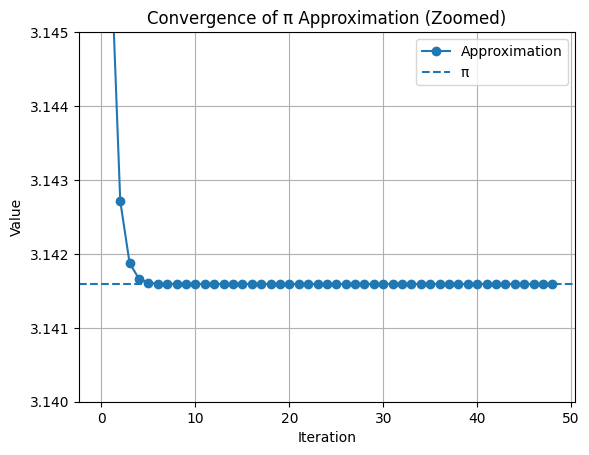

In [59]:
# convert to float only for plotting
vals = [float(v) for v in output[1:]]  # skip first invalid value
true_pi = float(mp.pi)

plt.figure()

plt.plot(vals, marker='o', label='Approximation')
plt.axhline(true_pi, linestyle='--', label='π')
plt.legend()

plt.ylim(3.14, 3.145)

plt.xlabel('Iteration')
plt.ylabel('Value')
plt.title('Convergence of π Approximation (Zoomed)')

plt.grid()

plt.show()

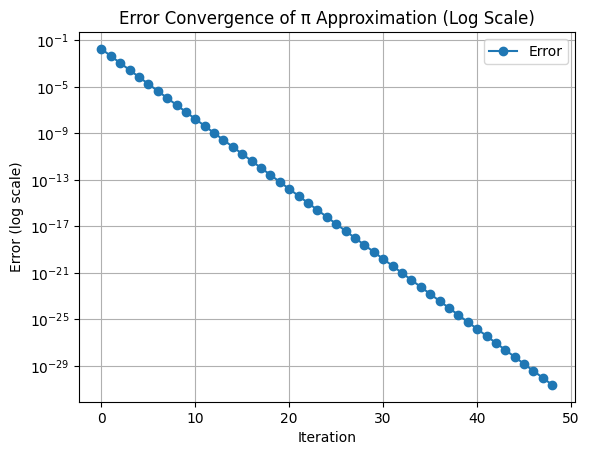

In [60]:
errors = [abs(v - mp.pi) for v in output[1:]]

plt.plot(errors, marker='o', label='Error')
plt.legend()
plt.yscale('log')

plt.xlabel("Iteration")
plt.ylabel("Error (log scale)")
plt.title("Error Convergence of π Approximation (Log Scale)")

plt.grid()
plt.show()